# Tufa Labs ARC3 submission

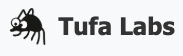

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# === duckmod: inject HUD auto-flag + transition-graph helpers into the python tool ===
# Splices duckmod/duck_tools.py (stdlib-only, same constraint as
# inference/utils/segmentation.py) into the sandbox bootstrap the way segmentation.py
# itself is spliced, and documents the two new helpers in the system prompt + the
# tool's own function-calling description. Runs after `bm`/`bm.solver` are unpickled
# (cell 5, "Load the benchmark") and before `bm.run(...)` starts (cell 7), so every
# ToolAgent constructed during the run picks up the patch. See
# results/duckmod-build-20260818.md for the full design writeup.

from inference.agent import tool_agent, python_tool_sandbox

_DUCK_TOOLS_SOURCE = '"""HUD/budget-bar auto-flagging and online transition-graph helpers for the\nARC-AGI-3 python-tool sandbox.\n\nStandard library only, no project imports, no `from __future__` import -- so\nthis source can be spliced verbatim into the Python-tool sandbox bootstrap,\nexactly like inference/utils/segmentation.py (same file this mirrors the\nconstraint from). No top-level side effects and no `__main__` guard belongs\nhere for the same reason segmentation.py has none: this text gets spliced\ninto a larger script and must not execute anything on its own when spliced.\nThe `__main__` self-test lives in a separate block that the notebook build\nstep strips before splicing (see taaf-duck-mod.ipynb cell 12 / the build\nnotes in results/duckmod-build-20260818.md).\n"""\n\nHUD_RATIO_THRESHOLD = 0.95\nHUD_ISOLATION_MIN_COUNT = 2\n\n\ndef _frame_rows(frame):\n    """Split a FrameView\'s `.ascii` into a list of character rows. `[]` if unavailable."""\n    ascii_text = getattr(frame, "ascii", None) if frame is not None else None\n    if not ascii_text:\n        return []\n    return ascii_text.split("\\n")\n\n\ndef hud_mask(history):\n    """Flag cells that behave like HUD/budget-bar chrome rather than gameplay state.\n\n    Walks consecutive frames in `history` (each entry exposes `.frame`) and flags a\n    cell `(row, col)` under either signature our campaign measured repeatedly:\n\n    - it changes on >=95% of frame-to-frame transitions (a ticking clock/budget bar), or\n    - it is, on its own, the ONLY cell that changed on at least 2 separate transitions\n      (an isolated ticker -- a counter no other move affects).\n\n    A pair of consecutive frames with mismatched shapes (a level change) is skipped,\n    not counted as "unchanged". Returns a plain `set` of `(row, col)` tuples -- subtract\n    it from a segmentation/diff before comparing frames or building a state key.\n    """\n    frames = [\n        entry.frame for entry in (history or []) if getattr(entry, "frame", None) is not None\n    ]\n    total_transitions = 0\n    change_count = {}\n    isolated_count = {}\n\n    for prev_frame, cur_frame in zip(frames, frames[1:]):\n        prev_rows = _frame_rows(prev_frame)\n        cur_rows = _frame_rows(cur_frame)\n        if not prev_rows or not cur_rows or len(prev_rows) != len(cur_rows):\n            continue\n        changed_this_tick = []\n        shape_ok = True\n        for r in range(len(prev_rows)):\n            prow, crow = prev_rows[r], cur_rows[r]\n            if len(prow) != len(crow):\n                shape_ok = False\n                break\n            for c in range(len(prow)):\n                if prow[c] != crow[c]:\n                    changed_this_tick.append((r, c))\n        if not shape_ok:\n            continue\n        total_transitions += 1\n        for cell in changed_this_tick:\n            change_count[cell] = change_count.get(cell, 0) + 1\n        if len(changed_this_tick) == 1:\n            cell = changed_this_tick[0]\n            isolated_count[cell] = isolated_count.get(cell, 0) + 1\n\n    flagged = set()\n    if total_transitions:\n        for cell, count in change_count.items():\n            if count / total_transitions >= HUD_RATIO_THRESHOLD:\n                flagged.add(cell)\n    for cell, count in isolated_count.items():\n        if count >= HUD_ISOLATION_MIN_COUNT:\n            flagged.add(cell)\n    return flagged\n\n\nclass TransitionGraph:\n    """Online state-transition graph built from *actually observed* (state, action)\n    -> next_state edges. Nothing survives between python-tool calls (the sandbox is a\n    fresh subprocess every call), so rebuild/feed it fresh from `history`/`transitions`\n    at the start of each call by replaying `.record(...)` over what\'s in `history`.\n\n    A graph built only from observed transitions can never assert a transition that\n    was not actually taken -- unlike a static/guessed reachability map, which this\n    campaign measured OVERCOUNTING reachability. Treat its output as a hypothesis\n    generator, never an oracle: a state with no recorded edges is UNEXPLORED, not a\n    dead end.\n    """\n\n    def __init__(self):\n        self.edges = {}  # state_key -> {action: next_state_key}\n        self.tried = {}  # state_key -> set(actions attempted from this state)\n\n    @staticmethod\n    def _key(state):\n        """Make any state representation hashable. bytes/str/int/float/tuple pass\n        through when they\'re actually hashable; anything else (list, dict, a tuple\n        containing an unhashable) is coerced through `repr`."""\n        if isinstance(state, (bytes, str, int, float, tuple)):\n            try:\n                hash(state)\n                return state\n            except TypeError:\n                pass\n        return repr(state)\n\n    def record(self, state, action, next_state):\n        """Record one observed (state, action) -> next_state edge. Returns the\n        normalized key for next_state."""\n        state_key = self._key(state)\n        next_key = self._key(next_state)\n        self.edges.setdefault(state_key, {})[action] = next_key\n        self.tried.setdefault(state_key, set()).add(action)\n        return next_key\n\n    def untried(self, state, all_actions):\n        """Actions not yet attempted from `state`, given the current action universe\n        (pass the live `valid_actions` -- it can change turn to turn)."""\n        state_key = self._key(state)\n        done = self.tried.get(state_key, set())\n        return [a for a in all_actions if a not in done]\n\n    def path_to_nearest_untried(self, current_state, all_actions):\n        """BFS over recorded edges from `current_state` for the nearest state (by edge\n        count) that still has an untried action. Returns `{"target": key, "path": [...]}`\n        where `path` is the action sequence to replay from `current_state`, or `None` if\n        nothing reachable via recorded edges has an untried action."""\n        start = self._key(current_state)\n        if self.untried(start, all_actions):\n            return {"target": start, "path": []}\n        visited = {start}\n        queue = [(start, [])]\n        head = 0\n        while head < len(queue):\n            state_key, path = queue[head]\n            head += 1\n            for action, next_key in self.edges.get(state_key, {}).items():\n                if next_key in visited:\n                    continue\n                visited.add(next_key)\n                new_path = path + [action]\n                if self.untried(next_key, all_actions):\n                    return {"target": next_key, "path": new_path}\n                queue.append((next_key, new_path))\n        return None\n\n\ndef _demo():\n    class _F:\n        def __init__(self, ascii_text):\n            self.ascii = ascii_text\n\n    class _H:\n        def __init__(self, frame):\n            self.frame = frame\n\n    # hud_mask signature 1: (0,0) ticks every frame (budget bar), (1,1) is the\n    # "real" gameplay cell that moves once, mid-run.\n    boards = [\n        "9..\\n.1.\\n...",\n        "0..\\n.1.\\n...",\n        "9..\\n.2.\\n...",\n        "0..\\n.2.\\n...",\n        "9..\\n.2.\\n...",\n    ]\n    history = [_H(_F(b)) for b in boards]\n    flagged = hud_mask(history)\n    assert (0, 0) in flagged, f"clock cell not flagged: {flagged}"\n    assert (1, 1) not in flagged, f"gameplay cell wrongly flagged: {flagged}"\n\n    # hud_mask signature 2: an isolated ticker that flips alone on 2+ transitions.\n    frames = ["...\\n...\\n...", "...\\n...\\n..X", "...\\n...\\n...", "...\\n...\\n..X"]\n    history2 = [_H(_F(b)) for b in frames]\n    flagged2 = hud_mask(history2)\n    assert (2, 2) in flagged2, f"isolated ticker not flagged: {flagged2}"\n\n    # level-change pair (mismatched shape) must be skipped, not crash / miscount.\n    history3 = [_H(_F("..\\n..")), _H(_F("...\\n...\\n..."))]\n    hud_mask(history3)  # must not raise\n\n    # TransitionGraph\n    g = TransitionGraph()\n    g.record("s0", "UP", "s1")\n    g.record("s0", "DOWN", "s0")\n    g.record("s1", "UP", "s2")\n    all_actions = ["UP", "DOWN", "LEFT", "RIGHT"]\n    assert set(g.untried("s0", all_actions)) == {"LEFT", "RIGHT"}\n    nearest = g.path_to_nearest_untried("s0", all_actions)\n    assert nearest == {"target": "s0", "path": []}, nearest\n\n    g.record("s0", "LEFT", "s0")\n    g.record("s0", "RIGHT", "s0")\n    nearest2 = g.path_to_nearest_untried("s0", all_actions)\n    assert nearest2 == {"target": "s1", "path": ["UP"]}, nearest2\n\n    # unhashable state (a list) must still work via repr coercion.\n    g.record([1, 2], "UP", [3, 4])\n    assert g.untried([1, 2], ["UP", "DOWN"]) == ["DOWN"]\n\n    print("duck_tools self-test OK")\n'

_HUD_PROMPT_TEXT = '\n- `hud_mask(history)` returns a `set` of `(row, col)` cells that behave like HUD/timer\n  chrome: cells that change on 95%+ of frame-to-frame transitions, or that are, alone,\n  the only cell that changed on 2+ separate transitions. Recomputed fresh from\n  `history` each call (nothing persists between calls).\n- `TransitionGraph()` is an online state-transition graph you build yourself from\n  `.record(state_key, action, next_state_key)` calls (state_key can be any value --\n  hashable ones pass through, others are coerced automatically). `.untried(state_key,\n  valid_actions)` lists actions never tried from a state; `.path_to_nearest_untried(\n  state_key, valid_actions)` BFS-searches recorded edges for the nearest state with an\n  untried action and returns `{"target": ..., "path": [actions...]}` or `None`.\n'
_PYTHON_ADDENDUM_TEXT = "\n- Before comparing frames or building a state key/signature, subtract `hud_mask(history)`\n  from the cells you diff or hash. A common failure mode is mistaking a ticking\n  clock/budget bar for gameplay state because it changes almost every action --\n  `hud_mask` flags exactly that pattern from observed history, not from a guess.\n- To avoid repeating explored actions or looping, build a `TransitionGraph`: call\n  `.record(state_key, action_taken, resulting_state_key)` after every action you take\n  (state_key can be `current_frame.ascii`, a `segmentation` hash, or your own derived\n  key). Before choosing an action, check `.untried(state_key, valid_actions)` for\n  actions you haven't tried from this exact state; if none remain, call\n  `.path_to_nearest_untried(state_key, valid_actions)` to find and navigate back to the\n  nearest state that still has one. Treat it as a hypothesis generator built only from\n  what you actually observed, never as a promise -- it has no edges for states you\n  haven't visited yet.\n"
_TOOL_DESC_TEXT = 'Two more helpers are preloaded: `hud_mask(history)` returns the set of `(row, col)`\ncells that look like HUD/timer chrome (subtract before diffing frames), and\n`TransitionGraph()` lets you record observed `(state, action) -> next_state` edges and\nquery `.untried(state, valid_actions)` / `.path_to_nearest_untried(state, valid_actions)`\nto avoid repeating actions and navigate back to unexplored states.'

# 1. Splice duck_tools.py's source into the sandbox bootstrap, right before the point
#    HOST_STDOUT is captured -- the same spot segmentation.py's own source lands
#    (module level in the bootstrap, so `hud_mask`/`TransitionGraph` become names in
#    the subprocess's module namespace, exactly like `segment_layer`).
_bootstrap = python_tool_sandbox._SANDBOX_BOOTSTRAP
_anchor = "HOST_STDOUT = sys.stdout\n"
assert _bootstrap.count(_anchor) == 1, (
    "duckmod: sandbox bootstrap anchor not found/not unique -- upstream bootstrap changed"
)
_bootstrap = _bootstrap.replace(_anchor, _DUCK_TOOLS_SOURCE + "\n\n" + _anchor)

# 2. Expose them as bare callables in the LLM's runtime_globals, the same pattern
#    `action` uses. Indentation is captured from the live anchor line rather than
#    hand-typed, so this survives the upstream file being re-indented.
_lines = _bootstrap.splitlines(keepends=True)
_out = []
_found_anchor2 = False
for _line in _lines:
    _out.append(_line)
    if _line.strip() == 'runtime_globals["action"] = action':
        _indent = _line[: len(_line) - len(_line.lstrip())]
        _out.append(f'{_indent}runtime_globals["hud_mask"] = hud_mask\n')
        _out.append(f'{_indent}runtime_globals["TransitionGraph"] = TransitionGraph\n')
        _found_anchor2 = True
assert _found_anchor2, "duckmod: runtime_globals anchor not found -- upstream bootstrap changed"
python_tool_sandbox._SANDBOX_BOOTSTRAP = "".join(_out)

# 3. Document both helpers in the always-resident system prompt. tool_agent.py does
#    `from inference.agent.prompts import PYTHON_ADDENDUM, ...` -- a from-import binds
#    the name into tool_agent's OWN module namespace, so patching
#    inference.agent.prompts.PYTHON_ADDENDUM here would silently do nothing:
#    _build_system_prompt resolves the bare name against tool_agent's globals, not
#    prompts'. Patch tool_agent's copy directly.
tool_agent.STRUCTURED_RUNTIME_STATE_ADDENDUM = (
    tool_agent.STRUCTURED_RUNTIME_STATE_ADDENDUM + _HUD_PROMPT_TEXT
)
tool_agent.PYTHON_ADDENDUM = tool_agent.PYTHON_ADDENDUM + _PYTHON_ADDENDUM_TEXT

# 4. Document them in the OpenAI function-calling tool description too (separate,
#    shorter budget -- tool_agent.py:154-165 / :1258-1280).
tool_agent._PYTHON_TOOL_DESCRIPTION = tool_agent._PYTHON_TOOL_DESCRIPTION + " " + _TOOL_DESC_TEXT

print(
    f"duckmod: sandbox bootstrap +{len(_DUCK_TOOLS_SOURCE)} chars, "
    f"system prompt +{len(_HUD_PROMPT_TEXT) + len(_PYTHON_ADDENDUM_TEXT)} chars, "
    f"tool description +{len(_TOOL_DESC_TEXT)} chars"
)

# === duckv5: accumulating world model + auto-injected transition digest/reset banner ===
# Stacks on duckmod's patch above (same cell, same already-imported `tool_agent`
# module from the `from inference.agent import tool_agent, python_tool_sandbox` line
# at the top of this cell) -- two independent, additional patches:
#   (1) ToolAgent._update_summarized_knowledge_from_assistant now ACCUMULATES each
#       labeled field turn-over-turn (turn-stamped, exact-duplicate-paragraph dedup,
#       bounded with oldest-first trim) instead of overwriting it every turn -- R7
#       sec5 measured this is the call site duckv4's world-model cap missed: the
#       field never grows under the harness's own overwrite design, so a char cap on
#       the PARSER never fires. Capping the MERGE step instead means the bound now
#       actually matters.
#   (2) ToolAgent._build_user_prompt gets a compact PROGRESS DIGEST block appended
#       every turn (per-action outcome counts, levels reached, last 5 actions) plus a
#       one-shot "!!! GAME RESET !!!" banner on the turn right after a GAME_OVER or
#       level regression. Targets R6's Mode 2 (anti-loop tooling present every
#       prompt, called 0/0 times across the 9 worst-thrashing games) and Mode 3
#       (silent resets erasing 75-300 actions of progress, confirmed in 6/9 and
#       inferred in a 7th) structurally: the harness computes and shows, there is
#       nothing new for the model to call.
# Neither patch touches HarnessSolver/_HarnessGameSession (v4's reallocator target) --
# out of scope for v5 by design (v4's reallocator measured inert on the games that
# matter and is not carried forward). See results/duckv5-build-20260820.md for the
# full design writeup.

_DUCKV5_ACCUM_SOURCE = '"""Accumulating world-model fields for the ARC-AGI-3 duck harness (duckv5, feature 1).\n\nR7 (results/wayfinder/R7-v4-postmortem.md sec5) measured why duckv4\'s char-length cap on\n`_extract_labeled_blocks` never fired: `_update_summarized_knowledge_from_assistant`\n(tool_agent.py:1105-1111) OVERWRITES each field with only the CURRENT turn\'s extracted\ntext -- the field never accumulates, so a 6000-char cap sits ~5x above the largest block\never written in a real 25-game run (measured max 3,501 chars). R6 (thrash forensics)\nmeasured the consequence directly: 8/9 zero-score games showed the persisted world-model\nfield frozen or empty for the whole run while the model\'s live, uncaptured reasoning kept\nre-deriving (and re-contradicting) facts already established earlier -- Mode 1, "scaffold\nstate amnesia."\n\nThis patches the MERGE step itself -- the same call site R7 names -- so each field\nACCUMULATES turn-stamped text instead of being replaced: new text from this turn is\nappended (with an exact-duplicate-paragraph dedup so a model that repeats itself doesn\'t\ninflate the field for free), and the whole field is bounded and trimmed oldest-first once\nit grows past the cap -- the tail-keep discipline duckv4\'s cap used\n(duckv4/duckv4_worldmodel_cap.py), except now the bound actually matters because growth\nis real.\n\nClass-level patch on `ToolAgent._update_summarized_knowledge_from_assistant` (an\nINSTANCE method, unlike duckv4\'s target which was a plain module-level function) -- same\nclass-level monkeypatch mechanics duckv3 used for `_build_user_prompt`\n(results/duckv3-build-20260819.md sec2), verified against the real bundle in\nverify_against_bundle.py, not just asserted here.\n\nSame-module patch, not a from-import copy: `_extract_scientist_note` lives directly in\ntool_agent.py and our replacement method calls `tool_agent_module._extract_scientist_note`\n(the module\'s own current attribute) rather than importing it elsewhere, so it stays\ncorrect even if a future patch on this same module replaces that function too.\n"""\nfrom __future__ import annotations\n\n# ponytail: one flat cap for all 7 fields, same simplification duckv4\'s cap made (R2\n# doesn\'t cite per-field sizes for this harness, only the mechanism). Mid the brief\'s\n# 6000-8000 char range. Narrow per-field once a real accumulating run\'s transcripts show\n# one field dominating growth.\nFIELD_CAP_CHARS = 7000\n\n_PATCH_MARKER = "_duckv5_accum_patched"\n_TURN_ATTR = "_duckv5_turn"\n\n\ndef _accumulate(existing: str, new_text: str, turn_label: str, cap: int = FIELD_CAP_CHARS) -> str:\n    """Append `new_text` stamped with `turn_label` to `existing`; skip if that exact\n    paragraph is already present anywhere in the field (dedup -- a model that re-states\n    an unchanged finding doesn\'t grow the field for free); trim oldest-first once the\n    result exceeds `cap`. Never raises on empty input."""\n    if not new_text:\n        return existing\n    if new_text in existing:\n        return existing\n    stamped = f"[{turn_label}] {new_text}"\n    combined = stamped if not existing else f"{existing}\\n{stamped}"\n    if len(combined) <= cap:\n        return combined\n    dropped = len(combined) - cap\n    return f"[compacted: {dropped} chars dropped]\\n{combined[-cap:]}"\n\n\ndef install_patch(tool_agent_module) -> None:\n    """Replace ToolAgent._update_summarized_knowledge_from_assistant so every labeled\n    field ACCUMULATES across turns instead of being overwritten each turn. Idempotent: a\n    second call no-ops rather than double-wrapping."""\n    cls = tool_agent_module.ToolAgent\n    if getattr(cls, _PATCH_MARKER, False):\n        return\n    if not hasattr(cls, "_update_summarized_knowledge_from_assistant"):\n        raise AttributeError(\n            "duckv5 accum: ToolAgent._update_summarized_knowledge_from_assistant not "\n            "found -- upstream tool_agent.py changed"\n        )\n    extract_note = tool_agent_module._extract_scientist_note\n\n    def _patched(self, content: str) -> None:\n        note = extract_note(content)\n        if not note:\n            return\n        turn = getattr(self, _TURN_ATTR, 0) + 1\n        setattr(self, _TURN_ATTR, turn)\n        turn_label = f"t{turn}"\n        for key, value in note.items():\n            if value:\n                existing = self._summarized_knowledge.get(key, "")\n                self._summarized_knowledge[key] = _accumulate(existing, value, turn_label)\n\n    setattr(cls, _PATCH_MARKER, True)\n    cls._update_summarized_knowledge_from_assistant = _patched\n\n\ndef _demo() -> None:\n    # --- _accumulate in isolation ---\n    assert _accumulate("", "first finding", "t1") == "[t1] first finding"\n    two_turns = _accumulate("[t1] first finding", "second finding", "t2")\n    assert two_turns == "[t1] first finding\\n[t2] second finding", two_turns\n\n    # exact-duplicate paragraph must not grow the field\n    dup = _accumulate(two_turns, "first finding", "t3")\n    assert dup == two_turns, "an exact-duplicate paragraph must be skipped, not re-stamped"\n\n    # trimming past the cap: oldest text drops, newest survives, marker present\n    cap = 200\n    grown = ""\n    for i in range(1, 40):\n        grown = _accumulate(grown, f"finding number {i} with some padding text", f"t{i}", cap=cap)\n    assert grown.startswith("[compacted: "), grown[:40]\n    assert "chars dropped]" in grown\n    assert "finding number 39" in grown, "the newest finding must survive trimming"\n    assert "finding number 1 " not in grown, "the oldest finding must be dropped"\n    assert len(grown) <= cap + 40, "marker overhead must stay small"\n\n    assert _accumulate("", "", "t1") == "", "empty new text must be a no-op"\n\n    # --- install_patch against a fake tool_agent-shaped module ---\n    class _FakeToolAgent:\n        def __init__(self):\n            self._summarized_knowledge = {}\n\n        # placeholder so hasattr() finds the target method before patching\n        def _update_summarized_knowledge_from_assistant(self, content):  # pragma: no cover\n            raise AssertionError("original method must be replaced by install_patch")\n\n    class _FakeModule:\n        ToolAgent = _FakeToolAgent\n\n        @staticmethod\n        def _extract_scientist_note(content):\n            # minimal stand-in: the whole content is one "world_model" paragraph\n            if not content.strip():\n                return {}\n            return {"world_model": content.strip(), "goal_model": ""}\n\n    mod = _FakeModule()\n    install_patch(mod)\n\n    agent = _FakeToolAgent()\n    agent._update_summarized_knowledge_from_assistant("turn one finding")\n    agent._update_summarized_knowledge_from_assistant("turn two finding")\n    agent._update_summarized_knowledge_from_assistant("turn three finding")\n    wm = agent._summarized_knowledge["world_model"]\n    assert "[t1] turn one finding" in wm, wm\n    assert "[t2] turn two finding" in wm, wm\n    assert "[t3] turn three finding" in wm, wm\n    assert "goal_model" not in agent._summarized_knowledge or not agent._summarized_knowledge.get("goal_model"), (\n        "an empty extracted field must not be written"\n    )\n\n    # exact repeat across turns (dedup applies through the real merge path too)\n    agent2 = _FakeToolAgent()\n    agent2._update_summarized_knowledge_from_assistant("same finding")\n    agent2._update_summarized_knowledge_from_assistant("same finding")\n    wm2 = agent2._summarized_knowledge["world_model"]\n    assert wm2.count("same finding") == 1, wm2\n\n    # per-instance turn counters are independent\n    agent3 = _FakeToolAgent()\n    agent3._update_summarized_knowledge_from_assistant("x")\n    assert getattr(agent, _TURN_ATTR) == 3\n    assert getattr(agent3, _TURN_ATTR) == 1\n\n    # idempotency: patching twice must not double-wrap\n    install_patch(mod)\n    agent4 = _FakeToolAgent()\n    agent4._update_summarized_knowledge_from_assistant("only once please")\n    assert agent4._summarized_knowledge["world_model"].count("only once please") == 1\n\n    # negative control: a module whose ToolAgent lacks the target method must fail\n    # loudly, not silently -- proves install_patch actually checks the real attribute\n    # rather than assuming it\'s there.\n    class _BrokenToolAgent:\n        pass\n\n    class _BrokenModule:\n        ToolAgent = _BrokenToolAgent\n\n    try:\n        install_patch(_BrokenModule())\n        raise AssertionError("expected AttributeError on a ToolAgent missing the target method")\n    except AttributeError:\n        pass  # expected\n\n    # restore: the correct module must still patch and behave correctly after the\n    # failed attempt above -- proves the negative control didn\'t leave shared state\n    # corrupted. A fresh ToolAgent-shaped class (never touched by the broken attempt)\n    # is used so this exercises a real install_patch call, not a no-op re-check.\n    class _RestoredToolAgent:\n        def __init__(self):\n            self._summarized_knowledge = {}\n\n        def _update_summarized_knowledge_from_assistant(self, content):  # pragma: no cover\n            raise AssertionError("original method must be replaced by install_patch")\n\n    class _FakeModule2:\n        ToolAgent = _RestoredToolAgent\n\n        @staticmethod\n        def _extract_scientist_note(content):\n            return {"world_model": content.strip()} if content.strip() else {}\n\n    install_patch(_FakeModule2())\n    agent5 = _RestoredToolAgent()\n    agent5._update_summarized_knowledge_from_assistant("post-failure finding")\n    assert "post-failure finding" in agent5._summarized_knowledge["world_model"]\n    print("duckv5_worldmodel_accum self-test OK")\n'
exec(compile(_DUCKV5_ACCUM_SOURCE, "<duckv5_worldmodel_accum>", "exec"), globals())
install_patch(tool_agent)
_duckv5_accum_chars = len(_DUCKV5_ACCUM_SOURCE)

_DUCKV5_DIGEST_SOURCE = '"""Auto-recorded transition digest + reset banner for the ARC-AGI-3 duck harness\n(duckv5, features 2 and 3).\n\nR6 (results/wayfinder/R6-thrash-forensics.md) measured Mode 2 across the 9 worst-thrashing\ngames: zero real `TransitionGraph()`/`hud_mask()` calls in 9/9 games -- the anti-loop\ntooling duckmod exposes is never invoked under turn-time pressure. And Mode 3: a silent\nmid-run GAME_OVER erased 75-300 actions of progress in 6-7/9 games, with the model taking\na full turn (or never) to even notice. Both are targeted the same way duckv3 targeted\n"the model doesn\'t call a tool for this": the harness computes the bookkeeping itself,\nserver-side, from data it already has (`history_entries`, the same\n`(action, before-frame, after-frame)` stream `_build_user_prompt` already receives), and\ninjects a small fixed-format block into every turn\'s prompt. The model calls nothing.\n\nSame patch point and same class-level monkeypatch mechanics duckv3 used for\n`_build_user_prompt` (tool_agent.py:1161, results/duckv3-build-20260819.md sec1-2) -- the\nclosest prior art for this design, reused here rather than re-derived. One `TransitionDigest`\ninstance is attached per `ToolAgent` INSTANCE (`self._duckv5_digest`, lazily created), the\nsame instance-attribute-not-dict pattern duckv3 chose specifically to avoid ever needing to\nkey state on a session/agent object (sidesteps the `_HarnessGameSession`-is-unhashable trap\nR7 sec-world-model-cap flags for any registry keyed that way -- there is no registry here).\n\nReset detection is NOT just "level number went down". R6\'s own header line: "All 9 games in\nthis report were stuck on level 1 for the entire run" -- so a GAME_OVER on any of the exact\ngames this feature targets can never show a level regression, because the level number never\nhad anywhere to fall from. The signature R6 actually measured, verbatim, twice ("reset the\nboard to the exact turn-1 layout"), is the GRID reverting to the state it was in when the\nCURRENT level was first entered, after having visibly diverged from it. That is what this\nmodule detects: per level, the grid recorded the moment that level was first seen is kept as\nits "entry state"; a later frame at the SAME level that matches the entry state again, having\ndiffered from it in between, is a reset. A level regression (level number decreasing) is also\nalways a reset and is checked first, cheaply, for games that DO demote the level number.\n"""\nfrom __future__ import annotations\n\nMAX_ACTIONS_SHOWN = 8\nLAST_N_ACTIONS = 5\nMAX_LEVELS_SHOWN = 6\n\n# ponytail: a flat action-count floor, not a learned one -- R6 doesn\'t cite a\n# minimum, only the shape of the failure (resets erasing 75-300 actions, i.e. two\n# orders of magnitude above this floor). Exists only to reject the trivial one-move-\n# then-back-again oscillation right after entering a level as a false "reset"; real\n# silent resets in R6 are never this close to a level\'s own entry point.\nMIN_ACTIONS_SINCE_LEVEL_ENTRY_FOR_RESET = 3\n\n_PATCH_MARKER = "_duckv5_digest_patched"\n\n\ndef _grid_diff_nonempty(prev_grid, cur_grid):\n    """True if any cell differs; False if identical or shapes don\'t line up (treated\n    as no evidence of a gameplay change either way -- never crashes)."""\n    if prev_grid is None or cur_grid is None:\n        return False\n    if len(prev_grid) != len(cur_grid):\n        return False\n    for prow, crow in zip(prev_grid, cur_grid):\n        if len(prow) != len(crow):\n            return False\n        if prow != crow:\n            return True\n    return False\n\n\ndef _normalize_action_name(action):\n    """Strip MOUSE(row,col)-style args down to the bare action symbol."""\n    if not action:\n        return ""\n    return str(action).split("(", 1)[0].strip()\n\n\nclass TransitionDigest:\n    """Per-game state: per-action tried/changed/noop tallies, the action-index (and\n    entry grid) each level was first seen at, the last N actions with their outcomes,\n    and single-shot reset-banner text -- all built only from transitions actually\n    present in `history_entries` (never guessed)."""\n\n    def __init__(self):\n        self._reset()\n\n    def _reset(self):\n        self._processed_len = 0\n        self.total_actions = 0\n        self.action_counts = {}  # name -> [tried, changed, noop]\n        self.level_first_seen = {}  # level -> action index it was first observed at\n        self.level_entry_grid = {}  # level -> grid recorded when that level was first seen\n        self.last_actions = []  # list of (name, outcome), most-recent-last, capped\n        self.last_level = None\n        self._actions_since_reset = 0\n        self._pending_reset = None  # str or None; consumed (single-shot) by render()\n\n    def _record_level(self, level, grid):\n        if level is not None and level not in self.level_first_seen:\n            self.level_first_seen[level] = self.total_actions\n            self.level_entry_grid[level] = grid\n\n    def _is_reset(self, prev_frame, cur_frame) -> bool:\n        if cur_frame.level < prev_frame.level:\n            return True  # explicit level demotion -- always a reset\n        if cur_frame.level != prev_frame.level:\n            return False  # a level-up is handled separately, never a reset\n        entry_grid = self.level_entry_grid.get(cur_frame.level)\n        if entry_grid is None or cur_frame.grid != entry_grid:\n            return False\n        if prev_frame.grid == entry_grid:\n            return False  # never left the entry state -- not a reversion, nothing lost\n        since_entry = self.total_actions - self.level_first_seen.get(cur_frame.level, 0)\n        return since_entry >= MIN_ACTIONS_SINCE_LEVEL_ENTRY_FOR_RESET\n\n    def _ingest(self, history_entries):\n        n = len(history_entries)\n        if n < self._processed_len:\n            # history shrank: a new session reused this instance (shouldn\'t happen in\n            # the per-game-instance design, but a stale block is worse than a fresh one).\n            self._reset()\n        start = self._processed_len\n        if start == 0 and n >= 1:\n            first_frame = history_entries[0].frame\n            if first_frame is not None:\n                self._record_level(first_frame.level, first_frame.grid)\n                self.last_level = first_frame.level\n\n        for i in range(max(start, 1), n):\n            prev_frame = history_entries[i - 1].frame\n            cur_frame = history_entries[i].frame\n            action_name = _normalize_action_name(history_entries[i].action)\n\n            self.total_actions += 1\n            self._actions_since_reset += 1\n            counts = self.action_counts.setdefault(action_name, [0, 0, 0])\n            counts[0] += 1  # tried\n\n            if prev_frame is None or cur_frame is None:\n                outcome = "noop"\n            elif self._is_reset(prev_frame, cur_frame):\n                outcome = "reset"\n            elif cur_frame.level > prev_frame.level:\n                outcome = "level_up"\n            elif _grid_diff_nonempty(prev_frame.grid, cur_frame.grid):\n                outcome = "changed"\n            else:\n                outcome = "noop"\n\n            if outcome in ("changed", "level_up"):\n                counts[1] += 1  # changed\n            else:\n                counts[2] += 1  # noop (also covers \'reset\' -- see module docstring scope)\n\n            self.last_actions.append((action_name, outcome))\n            if len(self.last_actions) > LAST_N_ACTIONS:\n                self.last_actions.pop(0)\n\n            if cur_frame is not None:\n                self._record_level(cur_frame.level, cur_frame.grid)\n\n            if outcome == "reset":\n                lost = self._actions_since_reset\n                before_level = prev_frame.level\n                after_level = cur_frame.level\n                self._pending_reset = (\n                    f"!!! GAME RESET: level went {before_level}->{after_level}, "\n                    f"{lost} actions of progress lost; your position/state assumptions "\n                    f"are now invalid !!!"\n                )\n                self._actions_since_reset = 0\n\n            if cur_frame is not None:\n                self.last_level = cur_frame.level\n\n        self._processed_len = n\n\n    def render(self, history_entries):\n        """Return the compact PROGRESS DIGEST block (plus a leading one-shot reset\n        banner, if a reset was just ingested) for this turn."""\n        self._ingest(history_entries or [])\n\n        lines = ["=== PROGRESS DIGEST (auto-tracked, no action needed) ==="]\n        lines.append(f"actions so far: {self.total_actions}")\n\n        levels_sorted = sorted(self.level_first_seen.items())[-MAX_LEVELS_SHOWN:]\n        if levels_sorted:\n            levels_text = ", ".join(f"L{lvl}@a{idx}" for lvl, idx in levels_sorted)\n        else:\n            levels_text = f"L{self.last_level or 1}@a0"\n        lines.append(f"levels reached: {levels_text}")\n\n        lines.append("action outcomes tried/changed/noop:")\n        shown = sorted(self.action_counts.items())[:MAX_ACTIONS_SHOWN]\n        if shown:\n            for name, (tried, changed, noop) in shown:\n                lines.append(f"  {name}: {tried}/{changed}/{noop}")\n        else:\n            lines.append("  (no actions taken yet)")\n\n        last_text = ", ".join(f"{name}:{outcome}" for name, outcome in self.last_actions) or "(none yet)"\n        lines.append(f"last {LAST_N_ACTIONS} actions: {last_text}")\n        lines.append("=== END DIGEST ===")\n\n        banner = self._pending_reset\n        self._pending_reset = None\n        if banner:\n            lines.insert(0, banner)\n\n        return "\\n".join(lines)\n\n\ndef install_patch(tool_agent_module) -> None:\n    """Monkeypatch tool_agent_module.ToolAgent._build_user_prompt so every turn\'s user\n    prompt gets an auto-computed PROGRESS DIGEST block (+ a one-shot reset banner)\n    appended. Idempotent -- a second call does not double-wrap."""\n    cls = tool_agent_module.ToolAgent\n    if getattr(cls, _PATCH_MARKER, False):\n        return\n    original = cls._build_user_prompt\n\n    def _patched(self, action_num, *, valid_actions=None, current_frame=None, history_entries=None, previous_step_summary=None):\n        base = original(\n            self,\n            action_num,\n            valid_actions=valid_actions,\n            current_frame=current_frame,\n            history_entries=history_entries,\n            previous_step_summary=previous_step_summary,\n        )\n        digest = getattr(self, "_duckv5_digest", None)\n        if digest is None:\n            digest = TransitionDigest()\n            self._duckv5_digest = digest\n        block = digest.render(history_entries or [])\n        return base + "\\n" + block\n\n    setattr(cls, _PATCH_MARKER, True)\n    cls._build_user_prompt = _patched\n\n\ndef _demo() -> None:\n    class _F:\n        def __init__(self, grid, level=1):\n            self.grid = grid\n            self.level = level\n\n    class _H:\n        def __init__(self, action, grid, level=1):\n            self.action = action\n            self.frame = _F(grid, level)\n\n    def board(mid):\n        return ((0, 0, 0), (0, mid, 0), (0, 0, 0))\n\n    # --- (a) basic tallies: tried/changed/noop counts, last-N, levels reached ---\n    # entry grid uses a value (9) never revisited later, so returning to mid=0 later\n    # in this same test is an ordinary state, not a reversion to the level\'s entry.\n    d = TransitionDigest()\n    history = [\n        _H("", board(9)),\n        _H("UP", board(1)),  # changed\n        _H("UP", board(1)),  # noop (mid unchanged)\n        _H("DOWN", board(0)),  # changed\n        _H("DOWN", board(0)),  # noop\n        _H("RIGHT", board(0)),  # noop\n    ]\n    block = d.render(history)\n    lines = block.split("\\n")\n    assert lines[0] == "=== PROGRESS DIGEST (auto-tracked, no action needed) ===", block\n    assert "actions so far: 5" in block, block\n    assert "L1@a0" in block, block\n    assert "UP: 2/1/1" in block, block\n    assert "DOWN: 2/1/1" in block, block\n    assert "RIGHT: 1/0/1" in block, block\n    assert "last 5 actions: UP:changed, UP:noop, DOWN:changed, DOWN:noop, RIGHT:noop" in block, block\n    assert len(lines) <= 25, f"block too long: {len(lines)} lines"\n    assert len(lines) >= 5, f"block suspiciously short: {len(lines)} lines"\n\n    # --- level-up: recorded in tallies AND in levels_reached, never flagged reset ---\n    d2 = TransitionDigest()\n    history2 = [\n        _H("", board(0), level=1),\n        _H("ACTION5", board(0), level=2),  # level_up\n    ]\n    block2 = d2.render(history2)\n    assert "ACTION5: 1/1/0" in block2, block2\n    assert "L1@a0" in block2 and "L2@a1" in block2, block2\n    assert "!!!" not in block2, "no reset must be flagged on a level-UP"\n\n    # --- (c1) reset banner via explicit level regression: fires exactly once, on the\n    # observation right after the regression, never again. ---\n    d3 = TransitionDigest()\n    history3 = [\n        _H("", board(0), level=1),\n        _H("UP", board(1), level=2),  # level_up to 2\n        _H("UP", board(1), level=2),  # ordinary action on level 2\n    ]\n    block3a = d3.render(history3)\n    assert "!!!" not in block3a, "no reset yet"\n\n    history3 = history3 + [_H("DOWN", board(0), level=1)]  # regression 2 -> 1\n    block3b = d3.render(history3)\n    assert "!!! GAME RESET: level went 2->1" in block3b, block3b\n    assert "actions of progress lost" in block3b, block3b\n\n    history3 = history3 + [_H("UP", board(1), level=1)]  # ordinary turn after the reset\n    block3c = d3.render(history3)\n    assert "!!!" not in block3c, "banner must be single-shot: gone on the NEXT render"\n\n    history3 = history3 + [_H("UP", board(1), level=1)]\n    block3d = d3.render(history3)\n    assert "!!!" not in block3d, "banner must stay gone on every later render"\n\n    # --- (c2) THE MOTIVATING CASE: a GAME_OVER on a game stuck at level 1 the whole\n    # run, per R6\'s own header finding ("All 9 games in this report were stuck on\n    # level 1 for the entire run"). Level number can never regress here -- it starts\n    # and stays at 1 -- so this can ONLY be caught by the grid reverting to its own\n    # level-1 entry state after having visibly diverged from it. ---\n    d4 = TransitionDigest()\n    genesis = board(0)\n    history4 = [\n        _H("", genesis, level=1),  # entry state for level 1\n        _H("UP", board(1), level=1),  # diverges\n        _H("RIGHT", board(2), level=1),  # diverges further\n        _H("DOWN", board(3), level=1),  # diverges further still\n    ]\n    block4a = d4.render(history4)\n    assert "!!!" not in block4a, "no reset yet -- board hasn\'t reverted"\n\n    history4 = history4 + [_H("MOUSE(1,1)", genesis, level=1)]  # silent GAME_OVER: reverts to genesis\n    block4b = d4.render(history4)\n    assert "!!! GAME RESET: level went 1->1" in block4b, block4b\n    assert "4 actions of progress lost" in block4b, block4b\n\n    history4 = history4 + [_H("UP", board(1), level=1)]\n    block4c = d4.render(history4)\n    assert "!!!" not in block4c, "single-shot banner must be gone the turn after"\n\n    # false-positive guard: a board that legitimately never left its own entry state\n    # must not be flagged (this is NOT a revert, nothing was lost).\n    d5 = TransitionDigest()\n    history5 = [_H("", genesis, level=1), _H("UP", genesis, level=1)]  # no-op press\n    block5 = d5.render(history5)\n    assert "!!!" not in block5, "never having diverged from entry state is not a reset"\n\n    # false-positive guard: an immediate one-move-then-back oscillation right after\n    # entering a level must not trip the MIN_ACTIONS_SINCE_LEVEL_ENTRY_FOR_RESET floor.\n    d6 = TransitionDigest()\n    history6 = [_H("", genesis, level=1), _H("UP", board(1), level=1), _H("DOWN", genesis, level=1)]\n    block6 = d6.render(history6)\n    assert "!!!" not in block6, "a same-level bounce this close to level entry must not be flagged"\n\n    # --- action names normalize (MOUSE(r,c) collapses to MOUSE) ---\n    d7 = TransitionDigest()\n    history7 = [\n        _H("", board(0)),\n        _H("MOUSE(3,4)", board(1)),\n        _H("MOUSE(5,6)", board(0)),\n    ]\n    block7 = d7.render(history7)\n    assert "MOUSE: 2/2/0" in block7, block7\n\n    # --- shape-mismatch frame (a level-glitch) must not crash; same-level treated as noop ---\n    d8 = TransitionDigest()\n    history8 = [\n        _H("", ((1, 2), (3, 4)), level=1),\n        _H("A", ((1, 2, 3), (4, 5, 6), (7, 8, 9)), level=1),  # same level, shape changed\n    ]\n    d8.render(history8)  # must not raise\n\n    print("duckv5_digest self-test OK")\n'
_duckv5_digest_ns = {}
exec(compile(_DUCKV5_DIGEST_SOURCE, "<duckv5_digest>", "exec"), _duckv5_digest_ns)
_duckv5_digest_ns["install_patch"](tool_agent)
_duckv5_digest_chars = len(_DUCKV5_DIGEST_SOURCE)

_DUCKV5_SYSTEM_PROMPT_ADDITION = "A PROGRESS DIGEST block is auto-appended each turn (no function call needed): per-action tried/changed/noop counts, levels reached and when, and your last 5 actions with outcomes. A '!!! GAME RESET !!!' line appears on the turn right after a GAME_OVER or level regression -- treat it as authoritative: your prior position and state assumptions are invalid."
tool_agent.STRUCTURED_RUNTIME_STATE_ADDENDUM = (
    tool_agent.STRUCTURED_RUNTIME_STATE_ADDENDUM + "\n" + _DUCKV5_SYSTEM_PROMPT_ADDITION
)

print(
    f"duckv5: patched ToolAgent._update_summarized_knowledge_from_assistant "
    f"(accumulate source {_duckv5_accum_chars} chars), "
    f"patched ToolAgent._build_user_prompt "
    f"(digest source {_duckv5_digest_chars} chars), "
    f"system prompt +{len(_DUCKV5_SYSTEM_PROMPT_ADDITION)} chars"
)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")